In [2]:
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src/config.py").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Nao encontrei src/config.py. Abra o notebook dentro do projeto.")
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
config = importlib.reload(config)
import utils
utils = importlib.reload(utils)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

config.entrar_na_raiz()
mambo, marche, base_cafe = config.carregar_bases_principais()


In [3]:
mambo.head()

,SKU,Titulo,Fabricante,Tipo Produto,Departamento,Categoria,Sub Categoria,GTIN,Modelo,Bytes,...,_3,_4,_5,_6,_7,_8,_9,_10,_11,CLUSTER PAO
0,2532,Café Torrado e Moído Superior Aviação 500g,Aviação,NaN,Mambo,Mercearia,NaN,7896331100648,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,#REF!
1,2533,Café Torrado e Moído 252 Graus a Vácuo Pilão 500g,Pilão,NaN,Mambo,Mercearia,NaN,7896089013849,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,#REF!
2,2534,Café Torrado e Moído 252° Graus Abre & Fecha P...,Pilão,NaN,Mambo,Mercearia,NaN,7896089013856,NaN,NaN,...,https://mambodelivery.vteximg.com.br/arquivos/...,https://mambodelivery.vteximg.com.br/arquivos/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,#REF!
3,2536,Café Torrado e Moído a Vácuo Tradicional 3 Cor...,3 Corações,NaN,Mambo,Mercearia,NaN,7896045102440,NaN,NaN,...,https://mambodelivery.vteximg.com.br/arquivos/...,https://mambodelivery.vteximg.com.br/arquivos/...,https://mambodelivery.vteximg.com.br/arquivos/...,https://mambodelivery.vteximg.com.br/arquivos/...,https://mambodelivery.vteximg.com.br/arquivos/...,https://mambodelivery.vteximg.com.br/arquivos/...,NaN,NaN,NaN,#REF!
4,2537,Cápsula de Café Aqtivus 8 Delta 55g com 10 Uni...,Delta Q,NaN,Mambo,Mercearia,NaN,5601082038537,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,#REF!


In [4]:
marche.head()

,SKU,Titulo,Fabricante,Tipo Produto,Departamento,Categoria,Sub Categoria,GTIN,Modelo,Bytes,...,Disponibilidade,Preco,Preço Oferta,Vendedor,Descricao,Descricao_1,URL,URL Imagem,URL Imagem_2,CLUSTER PAO
0,20041430,Café Solúvel NESCAFÉ Original 160g,Nescafé,NaN,Mercearia,Café,NaN,NaN,NaN,NaN,...,Indisponivel,0.0,0.0,NaN,NaN,NaN,https://marche.com.br/collections/mercearia/pr...,https://cdn.shopify.com/s/files/1/0587/8487/45...,https://cdn.shopify.com/s/files/1/0587/8487/45...,NaN
1,20068296,Cápsula de Café Dolce Gusto Neo Espresso Dark ...,Dolce gusto,NaN,Mercearia,Café,NaN,NaN,NaN,NaN,...,Indisponivel,0.0,0.0,NaN,NaN,NaN,https://marche.com.br/collections/mercearia/pr...,https://cdn.shopify.com/s/files/1/0587/8487/45...,https://cdn.shopify.com/s/files/1/0587/8487/45...,NaN
2,20068298,Cápsulas de Café Dolce Gusto Neo Lungo Cerrado...,Dolce gusto,NaN,Mercearia,Café,NaN,NaN,NaN,NaN,...,Indisponivel,0.0,0.0,NaN,NaN,NaN,https://marche.com.br/collections/mercearia/pr...,https://cdn.shopify.com/s/files/1/0587/8487/45...,https://cdn.shopify.com/s/files/1/0587/8487/45...,NaN
3,20068295,Cápsula de Café Dolce Gusto Neo Espresso Delic...,Dolce gusto,NaN,Mercearia,Café,NaN,NaN,NaN,NaN,...,Indisponivel,0.0,0.0,NaN,NaN,NaN,https://marche.com.br/collections/mercearia/pr...,https://cdn.shopify.com/s/files/1/0587/8487/45...,https://cdn.shopify.com/s/files/1/0587/8487/45...,NaN
4,20068297,Cápsula de Café Dolce Gusto Neo Espresso Sul d...,Dolce gusto,NaN,Mercearia,Café,NaN,NaN,NaN,NaN,...,Indisponivel,0.0,0.0,NaN,NaN,NaN,https://marche.com.br/collections/mercearia/pr...,https://cdn.shopify.com/s/files/1/0587/8487/45...,https://cdn.shopify.com/s/files/1/0587/8487/45...,NaN


In [5]:
base_cafe.head()

,Código,Descrição,Departamento,Categoria/Setor,Marca,Famlíia,Código do Fabricante,Código de Barras,SKU Monitorado,Website Monitorado,URL Produto Monitorado,Data,Média Preço Normal,Média Preço Oferta
0,1038723,Café Torrado e Moído Extraforte Pilão Pacote 500g,Alimentos,Básico da despensa,pa,NaN,NaN,7896089013399,1038723,www.paodeacucar.com,https://www.paodeacucar.com/produto/292186/caf...,2026-03-08,27.49,27.49
1,1038723,Café Torrado e Moído Extraforte Pilão Pacote 500g,Alimentos,Básico da despensa,pa,NaN,NaN,7896089013399,1038723,www.paodeacucar.com,https://www.paodeacucar.com/produto/292186/caf...,2026-03-07,27.49,27.49
2,1038723,Café Torrado e Moído Extraforte Pilão Pacote 500g,Alimentos,Básico da despensa,pa,NaN,NaN,7896089013399,1038723,www.paodeacucar.com,https://www.paodeacucar.com/produto/292186/caf...,2026-03-06,27.49,27.49
3,183567,Café Torrado e Moído Extraforte 3 Corações Pac...,Alimentos,Básico da despensa,pa,NaN,NaN,7896005801529,183567,www.paodeacucar.com,https://www.paodeacucar.com/produto/57156/cafe...,2026-03-08,27.99,27.99
4,183567,Café Torrado e Moído Extraforte 3 Corações Pac...,Alimentos,Básico da despensa,pa,NaN,NaN,7896005801529,183567,www.paodeacucar.com,https://www.paodeacucar.com/produto/57156/cafe...,2026-03-07,27.99,27.99


In [6]:
base_cafe["Marca"][base_cafe["Marca"].duplicated()]

1               pa
2               pa
3               pa
4               pa
5               pa
           ...    
1042       Qualitá
1043       Qualitá
1044    3 Corações
1045    3 Corações
1046    3 Corações
Name: Marca, Length: 1006, dtype: str

In [7]:
contagem = base_cafe["Marca"].value_counts()

contagem[contagem > 1]

Marca
3 Corações               117
pa                        90
Nescafé Dolce Gusto       84
L'OR                      75
Pilão                     69
Qualitá                   66
Nescafé                   60
Orfeu                     54
Baggio                    51
Illy                      39
União                     39
Santa Monica              39
Starbucks                 24
L'Or                      21
Nescafé Gold              21
Native                    15
ORFEU                     15
Astro Cafe                15
Juan Valdez               15
Constantino               15
Melitta                   12
Bravo Cafe                12
Três                       9
Caboclo                    9
Café Brasileiro            9
Café do Ponto              9
Qualitá Exclusive          9
3 Chá                      6
Café União Pouch 250g      6
Prima Qualitá              6
Café do Centro             6
Tres Coracoes              3
do Ponto                   3
Moderato                   3
Genérico

In [8]:
base_cafe[base_cafe["Marca"] == "pa"]

,Código,Descrição,Departamento,Categoria/Setor,Marca,Famlíia,Código do Fabricante,Código de Barras,SKU Monitorado,Website Monitorado,URL Produto Monitorado,Data,Média Preço Normal,Média Preço Oferta
0,1038723,Café Torrado e Moído Extraforte Pilão Pacote 500g,Alimentos,Básico da despensa,pa,NaN,NaN,7896089013399,1038723,www.paodeacucar.com,https://www.paodeacucar.com/produto/292186/caf...,2026-03-08,27.49,27.49
1,1038723,Café Torrado e Moído Extraforte Pilão Pacote 500g,Alimentos,Básico da despensa,pa,NaN,NaN,7896089013399,1038723,www.paodeacucar.com,https://www.paodeacucar.com/produto/292186/caf...,2026-03-07,27.49,27.49
2,1038723,Café Torrado e Moído Extraforte Pilão Pacote 500g,Alimentos,Básico da despensa,pa,NaN,NaN,7896089013399,1038723,www.paodeacucar.com,https://www.paodeacucar.com/produto/292186/caf...,2026-03-06,27.49,27.49
3,183567,Café Torrado e Moído Extraforte 3 Corações Pac...,Alimentos,Básico da despensa,pa,NaN,NaN,7896005801529,183567,www.paodeacucar.com,https://www.paodeacucar.com/produto/57156/cafe...,2026-03-08,27.99,27.99
4,183567,Café Torrado e Moído Extraforte 3 Corações Pac...,Alimentos,Básico da despensa,pa,NaN,NaN,7896005801529,183567,www.paodeacucar.com,https://www.paodeacucar.com/produto/57156/cafe...,2026-03-07,27.99,27.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000,1415113,Café Torrado em Capsulas Tereza do Quilombo 50g,NaN,NaN,pa,NaN,NaN,7898972425074,1415113,www.paodeacucar.com,https://www.paodeacucar.com/produto/1640735/ca...,2026-03-07,30.99,30.99
1001,1415113,Café Torrado em Capsulas Tereza do Quilombo 50g,NaN,NaN,pa,NaN,NaN,7898972425074,1415113,www.paodeacucar.com,https://www.paodeacucar.com/produto/1640735/ca...,2026-03-06,NaN,NaN
1032,1415224,Café Solúvel Liofilizado Intenso Nescafé Gold ...,NaN,NaN,pa,NaN,NaN,8445291748590,1415224,www.paodeacucar.com,https://www.paodeacucar.com/produto/1641745/ca...,2026-03-08,35.19,35.19
1033,1415224,Café Solúvel Liofilizado Intenso Nescafé Gold ...,NaN,NaN,pa,NaN,NaN,8445291748590,1415224,www.paodeacucar.com,https://www.paodeacucar.com/produto/1641745/ca...,2026-03-07,40.32,40.32


In [9]:
mambo.shape
marche.shape
base_cafe.shape

(1047, 14)

In [10]:
base_total = pd.concat([base_cafe, mambo, marche], ignore_index=True)

In [11]:
base_recente = (
    base_cafe
    .sort_values("Data")
    .groupby("Código")
    .last()
    .reset_index()
)

In [12]:
base_recente.groupby("Marca")["Média Preço Normal"].mean().sort_values()

Marca
Café União Pouch 250g    16.990000
Café Brasileiro          19.590000
Embafreezer              19.980000
do Ponto                 19.990000
Qualitá Exclusive        22.623333
Genérico                 22.990000
Nescafé                  23.610000
Bravo Cafe               23.786667
Qualitá                  24.121818
Astro Cafe               24.890000
L'Or                     25.790000
Tres Coracoes            25.990000
Nescafé Gold             26.891429
L'OR                     26.982800
Três                     26.990000
União                    27.215000
QUALITA                  28.390000
Nescafé Dolce Gusto      28.677407
Café do Ponto            28.823333
Illy                     29.691818
Melitta                  29.990000
Pilão                    30.081905
Baggio                   30.284118
pa                       30.476207
C Annata                 30.990000
3 Corações               31.507632
Native                   31.990000
Santa Monica             33.617692
Café do Centro

In [13]:
base_recente["Marca"].value_counts()

Marca
3 Corações               39
pa                       30
Nescafé Dolce Gusto      28
L'OR                     25
Pilão                    23
Qualitá                  22
Nescafé                  20
Orfeu                    18
Baggio                   17
Illy                     13
Santa Monica             13
União                    13
Starbucks                 8
Nescafé Gold              7
L'Or                      7
Native                    5
Juan Valdez               5
Astro Cafe                5
Constantino               5
ORFEU                     5
Melitta                   4
Bravo Cafe                4
Café Brasileiro           3
Caboclo                   3
Café do Ponto             3
Três                      3
Qualitá Exclusive         3
Café do Centro            2
Café União Pouch 250g     2
3 Chá                     2
Prima Qualitá             2
do Ponto                  1
Taeq                      1
C Annata                  1
Tres Coracoes             1
Bravo         

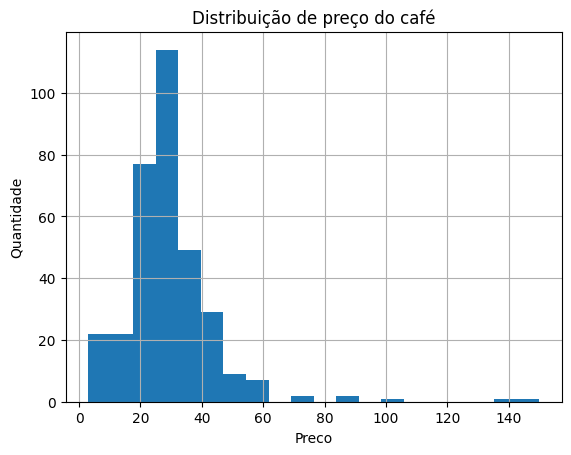

In [14]:
base_recente["Média Preço Normal"].hist(bins=20)

plt.title("Distribuição de preço do café")
plt.xlabel("Preco")
plt.ylabel("Quantidade")

plt.show()

In [15]:
base_recente.groupby("Website Monitorado")["Média Preço Normal"].mean()

Website Monitorado
www.paodeacucar.com    29.848036
Name: Média Preço Normal, dtype: float64

In [16]:
base_recente = base_recente.rename(columns={
    "Descrição": "Titulo",
    "Marca": "Fabricante",
    "Média Preço Normal": "Preco",
    "Website Monitorado": "Loja"
})

print(base_recente)

      Código                                             Titulo Departamento  \
0     106498  Café Torrado e Moído Tradicional Café Brasilei...    Alimentos   
1     183567  Café Torrado e Moído Extraforte 3 Corações Pac...    Alimentos   
2     250665  Café Torrado e Moído Tradicional Caboclo Pacot...    Alimentos   
3     250672  Café Solúvel Granulado Extraforte Nescafé Orig...    Alimentos   
4     250702  Café Torrado e Moído Tradicional Pilão Pacote ...          NaN   
..       ...                                                ...          ...   
344  7641688    Café Torrado e Moído Pilão 252 Graus Pouch 500g          NaN   
345  7757617  Café Torrado e Moído Baggio Caffé.com Premium ...          NaN   
346  8322463  Café com Leite Solúvel Clássico Melitta Lata 200g          NaN   
347  8704672  Café Torrado em Grãos Espresso 3 Corações Gour...    Alimentos   
348  8888341  Café Solúvel em Pó Espresso Intenso Nescafé Go...          NaN   

        Categoria/Setor       Fabricant

In [17]:
mambo = mambo.rename(columns={
    "Titulo": "Titulo",
    "Fabricante": "Fabricante",
    "Preco": "Preco"
})

mambo["Loja"] = "Mambo"

mambo = mambo[["Titulo","Fabricante","Preco","Loja"]]
print(mambo)

                                                Titulo       Fabricante  \
0           Café Torrado e Moído Superior Aviação 500g          Aviação   
1    Café Torrado e Moído 252 Graus a Vácuo Pilão 500g            Pilão   
2    Café Torrado e Moído 252° Graus Abre & Fecha P...            Pilão   
3    Café Torrado e Moído a Vácuo Tradicional 3 Cor...       3 Corações   
4    Cápsula de Café Aqtivus 8 Delta 55g com 10 Uni...          Delta Q   
..                                                 ...              ...   
493  Café Torrado e Moído Aroma de Baunilha Baggio ...           Baggio   
494  Café Torrado e Moído Mantiqueira de Minas Café...  Café Brasileiro   
495  Café Torrado e Moído Mogiana Paulista Café Bra...  Café Brasileiro   
496  Café Torrado e Moído Caparaó Café Brasileiro G...  Café Brasileiro   
497                     Café Cremoso Nescafé Lata 150g          Nescafé   

     Preco   Loja  
0    54.98  Mambo  
1    43.49  Mambo  
2    43.49  Mambo  
3    27.99  Mambo  

In [18]:
marche["Loja"] = "St Marche"

marche = marche[["Titulo","Fabricante","Preco","Loja"]]

base_recente = base_recente[["Titulo","Fabricante","Preco","Loja"]]

In [19]:
base_total = pd.concat([base_recente, mambo, marche], ignore_index=True)

In [20]:
base_total.groupby("Fabricante")["Preco"].mean()

Fabricante
3 Chá         39.990000
3 Corações    27.263179
Astro Cafe    24.890000
Aviação       54.980000
Baggio        31.911765
                ...    
Três          26.990000
União         25.970000
Villa Piva    17.438571
do Ponto      19.990000
pa            30.476207
Name: Preco, Length: 80, dtype: float64

In [21]:
pd.crosstab(base_total["Fabricante"], base_total["Loja"])

Loja,Mambo,St Marche,www.paodeacucar.com
Fabricante,,,
3 Chá,0,0,2
3 Corações,92,65,39
Astro Cafe,0,0,5
Aviação,2,0,0
Baggio,19,15,17
...,...,...,...
Três,0,0,3
União,9,3,13
Villa Piva,0,7,0


In [22]:
base_total.pivot_table(
    index="Titulo",
    columns="Loja",
    values="Preco"
)

Loja,Mambo,St Marche,www.paodeacucar.com
Titulo,,,
CAFÉ FAZENDA PESSEGUEIRO Torra Média Cápsulas com 10 Unidades,NaN,37.19,NaN
Cafe 3 Corações Torrado e Moído Rituais Frutas Secas 250g,NaN,40.99,NaN
Cafe Capsula Torra Italiana Display Com 10 Unidades,NaN,NaN,27.99
Cafe Soluvel com Leite Descafeinado Sem Lactose 3 Coracoes Lata 200g,28.98,NaN,NaN
Cafe Torrado em Grãos Acauã Orfeu Varietais Pacote 250g,NaN,NaN,46.99
...,...,...,...
Especial de Café 180g,NaN,NaN,22.99
Kit Café Casa Brasil Edição Limitada 250g,NaN,0.00,NaN
Kit Cápsula de Café + Caneca Nespresso & Starbucks Pack com 40 Unidades Kit Cápsula de Café + Caneca Nespresso & Starbucks Caixa com 40 Unidades,127.49,NaN,NaN


In [23]:
comparacao = base_total.pivot_table(
    index="Titulo",
    columns="Loja",
    values="Preco"
)

comparacao.head(20)

Loja,Mambo,St Marche,www.paodeacucar.com
Titulo,,,
CAFÉ FAZENDA PESSEGUEIRO Torra Média Cápsulas com 10 Unidades,NaN,37.19,NaN
Cafe 3 Corações Torrado e Moído Rituais Frutas Secas 250g,NaN,40.99,NaN
Cafe Capsula Torra Italiana Display Com 10 Unidades,NaN,NaN,27.99
Cafe Soluvel com Leite Descafeinado Sem Lactose 3 Coracoes Lata 200g,28.98,NaN,NaN
Cafe Torrado em Grãos Acauã Orfeu Varietais Pacote 250g,NaN,NaN,46.99
Café 3 CORAÇÕES Cápsulas Espresso Supremo Com 10 Cápsulas,NaN,26.90,NaN
Café 3 CORAÇÕES Cápsulas Espresso Vibrante Com 10 Cápsulas,NaN,26.90,NaN
Café 3 CORAÇÕES Solúvel Descafeinado 50g,NaN,0.00,NaN
Café 3 CORAÇÕES Solúvel Liofilizado 100% Arábica Vidro 100g,NaN,35.99,NaN


In [24]:
base_total.groupby("Loja")["Titulo"].count()

Loja
Mambo                  498
St Marche              366
www.paodeacucar.com    349
Name: Titulo, dtype: int64

In [25]:
base_total.groupby("Loja")["Preco"].mean().sort_values(ascending=False)

Loja
Mambo                  31.221928
www.paodeacucar.com    29.848036
St Marche              27.742486
Name: Preco, dtype: float64

A análise de preços de café entre os supermercados
indica diferenças claras de posicionamento. O St Marche
apresenta o maior preço médio R$36 e mediana de R$31,
sugerindo presença significativa de produtos premium.

In [26]:
base_total.groupby("Loja")["Preco"].median().sort_values()

Loja
www.paodeacucar.com    27.965
Mambo                  28.490
St Marche              28.990
Name: Preco, dtype: float64

- St Marche é o supermercado mais premium

- Pão de Açúcar tem preços mais competitivos

In [27]:
analise_loja = (
    base_total
    .groupby("Loja")["Preco"]
    .agg(["mean","median","min","max","count"])
    .reset_index()
)

analise_loja

,Loja,mean,median,min,max,count
0,Mambo,31.221928,28.490,0.00,194.98,498
1,St Marche,27.742486,28.990,0.00,165.29,366
2,www.paodeacucar.com,29.848036,27.965,2.99,149.90,336


In [28]:
# Salvamento desativado para preservar os relatorios ja gerados

In [29]:
analise_fabricante = (
    base_total.groupby("Fabricante")["Preco"]
    .agg(["mean","median","min","max","count"])
    .sort_values("mean")
    .reset_index()
)

# Calcular range
analise_fabricante["range"] = (analise_fabricante["max"] - analise_fabricante["min"]).round(2)

# Arredondar
analise_fabricante[["mean","median","min","max"]] = analise_fabricante[["mean","median","min","max"]].round(2)

In [30]:
# Salvamento desativado para preservar os relatorios ja gerados

In [31]:
analise_mix = pd.crosstab(
    base_total["Fabricante"], base_total["Loja"]
)

analise_mix

Loja,Mambo,St Marche,www.paodeacucar.com
Fabricante,,,
3 Chá,0,0,2
3 Corações,92,65,39
Astro Cafe,0,0,5
Aviação,2,0,0
Baggio,19,15,17
...,...,...,...
Três,0,0,3
União,9,3,13
Villa Piva,0,7,0


In [32]:
# Salvamento desativado para preservar os relatorios ja gerados

In [33]:
analise_preco = base_total["Preco"].describe().round(2)

analise_preco

count    1200.00
mean       29.78
std        21.17
min         0.00
25%        19.99
50%        27.99
75%        36.92
max       194.98
Name: Preco, dtype: float64

## Analise de preco normalizado por peso

As proximas celulas mantem a logica que alimenta os graficos 4 e 5, mas no notebook a saida fica em tabela e texto. Os graficos continuam sendo gerados pelo script `src/graficos.py`.


In [34]:
# Carrega o resumo de preco por loja ja normalizado para 500g.
preco_normalizado_loja = (
    pd.read_csv(config.TABELAS_DIR / "05_analise_preco_normalizado_peso_loja.csv")
    .sort_values("preco_500g_mediano", ascending=False)
)

utils.tabela_negrito(preco_normalizado_loja)


,loja,produtos,produtos_com_peso,cobertura_peso_pct,preco_mediano,preco_500g_mediano,preco_100g_mediano,preco_unidade_mediano
1,Paodeacucar,319,306,95.92,27.99,112.38,22.48,2.70
0,Mambo,456,436,95.61,29.90,99.90,19.98,2.55
2,St Marche,282,204,72.34,31.99,99.86,19.97,2.95


In [43]:
# Gera uma leitura textual do grafico 4 sem renderizar o grafico no notebook.
loja_maior_preco_500g = preco_normalizado_loja.iloc[0]
loja_menor_preco_500g = preco_normalizado_loja.iloc[-1]
diferenca_preco_500g = (
    loja_maior_preco_500g["preco_500g_mediano"]
    - loja_menor_preco_500g["preco_500g_mediano"]
)


No preco mediano normalizado por 500g, Paodeacucar aparece com o maior valor (R$ 112.38), enquanto St Marche tem o menor (R$ 99.86). A diferenca entre elas e de R$ 12.52.


In [36]:
# Carrega a analise por faixa de peso e remove produtos sem peso identificado.
preco_faixa_peso_loja = pd.read_csv(config.TABELAS_DIR / "04_analise_faixa_peso_loja.csv")
preco_faixa_peso_loja = preco_faixa_peso_loja[
    preco_faixa_peso_loja["faixa_peso"] != "sem_peso"
].copy()

ordem_faixa_peso = ["ate_100g", "101g_250g", "251g_500g", "501g_1kg"]
preco_faixa_peso_loja["faixa_peso"] = pd.Categorical(
    preco_faixa_peso_loja["faixa_peso"],
    categories=ordem_faixa_peso,
    ordered=True,
)
preco_faixa_peso_loja = preco_faixa_peso_loja.sort_values("faixa_peso")

utils.tabela_negrito(preco_faixa_peso_loja)


,loja,faixa_peso,produtos,preco_mediano,preco_500g_mediano
3,Mambo,ate_100g,213,25.49,219.90
8,Paodeacucar,ate_100g,167,24.99,219.90
13,St Marche,ate_100g,92,29.90,240.29
0,Mambo,101g_250g,158,32.48,79.92
5,Paodeacucar,101g_250g,95,32.99,77.98
10,St Marche,101g_250g,71,35.99,84.98
1,Mambo,251g_500g,57,43.49,43.49
6,Paodeacucar,251g_500g,39,34.99,34.99
11,St Marche,251g_500g,38,41.50,41.50
2,Mambo,501g_1kg,8,143.48,71.74


In [44]:
# Gera uma leitura textual do grafico 5 sem renderizar o grafico no notebook.
maior_preco_faixa = preco_faixa_peso_loja.sort_values(
    "preco_500g_mediano",
    ascending=False,
).iloc[0]
faixa_251_500g = preco_faixa_peso_loja[
    preco_faixa_peso_loja["faixa_peso"] == "251g_500g"
]
loja_menor_251_500g = faixa_251_500g.sort_values("preco_500g_mediano").iloc[0]



A maior mediana proporcional por 500g esta na faixa ate_100g da loja St Marche (R$ 240.29). Na faixa 251g_500g, melhor para comparar pacotes tradicionais, Paodeacucar apresenta a menor mediana (R$ 34.99).

In [38]:
# Salvamento desativado para preservar os relatorios ja gerados

In [39]:
bins = [0,20,30,40,50,100]

base_total["Faixa_Preco"] = pd.cut(base_total["Preco"], bins=bins)

base_total["Faixa_Preco"].value_counts().sort_index(ascending=True)

Faixa_Preco
(0, 20]      177
(20, 30]     391
(30, 40]     271
(40, 50]     143
(50, 100]     73
Name: count, dtype: int64

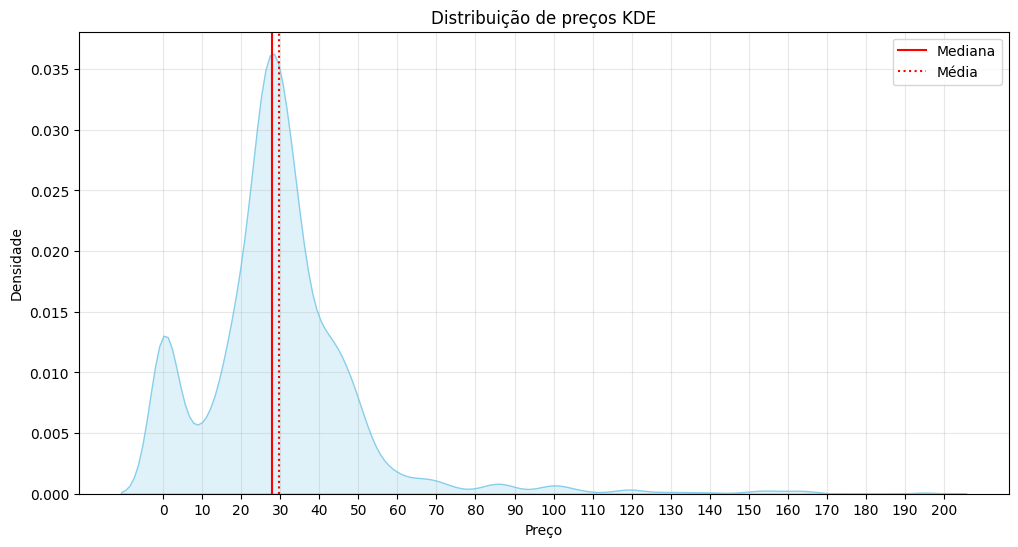

In [40]:
plt.figure(figsize=(12, 6))

sns.kdeplot(base_total["Preco"], fill=True, bw_adjust=0.7, color="skyblue")

plt.axvline(base_total["Preco"].median(), color="red", linestyle="solid", label="Mediana")
plt.axvline(base_total["Preco"].mean(), color="red", linestyle="dotted", label="Média")

plt.title("Distribuição de preços KDE")
plt.xlabel("Preço")
plt.xticks(np.arange(0, 210, 10))
plt.ylabel("Densidade")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [41]:
media = base_total['Preco'].mean()
std = base_total['Preco'].std()

# Produtos dentro da faixa ±1 std
dentro_1std = base_total[(base_total['Preco'] >= media - std) & (base_total['Preco'] <= media + std)]

# Porcentagem real
percent_dentro_1std = len(dentro_1std) / len(base_total) * 100
print(f'Percentual real dentro de ±1 std: {percent_dentro_1std:.2f}%')

Percentual real dentro de ±1 std: 78.73%


A maior parte dos produtos está concentrada na faixa ±1 std.

Os outliers (muito baratos ou caros) distorcem a média, mas são poucos.

A mediana é mais representativa do preço típico da maioria dos produtos.

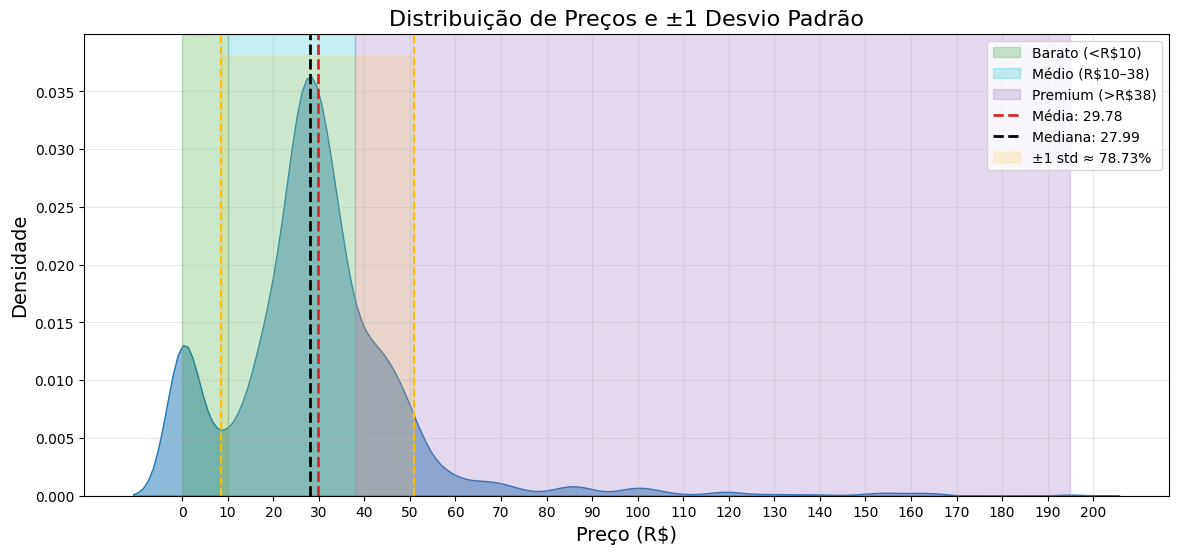

In [42]:
media = base_total['Preco'].mean()
mediana = base_total['Preco'].median()
std = base_total['Preco'].std()

lower = media - std
upper = media + std

dentro_1std = base_total[(base_total['Preco'] >= lower) & (base_total['Preco'] <= upper)]
percent_dentro_1std = len(dentro_1std) / len(base_total) * 100

plt.figure(figsize=(14,6))

# Curva KDE
sns.kdeplot(base_total['Preco'], fill=True, bw_adjust=0.7, color='#1f77b4', alpha=0.5)

# Faixas de preço
plt.axvspan(0, 10, color='#2ca02c', alpha=0.25, label='Barato (<R$10)')
plt.axvspan(10, 38, color='#17becf', alpha=0.25, label='Médio (R$10–38)')
plt.axvspan(38, base_total['Preco'].max(), color='#9467bd', alpha=0.25, label='Premium (>R$38)')

# Média e mediana
plt.axvline(media, color='#d62728', linestyle='--', linewidth=2, label=f'Média: {media:.2f}')
plt.axvline(mediana, color='black', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.2f}')

# ±1 std
plt.axvline(lower, color='#ffbf00', linestyle='--', linewidth=1.5)
plt.axvline(upper, color='#ffbf00', linestyle='--', linewidth=1.5)

plt.fill_betweenx(
    y=[0, plt.gca().get_ylim()[1]],
    x1=lower,
    x2=upper,
    color='#ffbf00',
    alpha=0.15,
    label=f'±1 std ≈ {percent_dentro_1std:.2f}%'
)

plt.title('Distribuição de Preços e ±1 Desvio Padrão', fontsize=16)
plt.xlabel('Preço (R$)', fontsize=14)
plt.xticks(np.arange(0, 210, 10))
plt.ylabel('Densidade', fontsize=14)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

A maior parte dos produtos está concentrada em preços médios, o que indica que a estratégia de preço e estoque deve priorizar essa faixa.

A faixa ±1 std cobre praticamente toda a distribuição central (85,74%), mostrando onde o consumidor típico encontra produtos.

Produtos fora dessa faixa são exceções, que podem ser usados para promoções, ofertas de entrada ou produtos premium.

Média > mediana → indica assimetria à direita, causada por produtos caros, então a mediana reflete melhor o preço típico do catálogo.